# RNA → Protein Autoencoder for **Unpaired** Samples — Per-Variety Analysis

This notebook is the unpaired-sample counterpart of `rna_protein_per_variety.ipynb`.

Use it when RNA-seq and proteomics were measured on **different biological samples**, but both experiments share the same factorial design, for example:

```text
Variety A
  RNA:     control/infected × 4 timepoints × independent RNA replicates
  Protein: control/infected × 4 timepoints × independent protein replicates

Variety B
  RNA:     control/infected × 4 timepoints × independent RNA replicates
  Protein: control/infected × 4 timepoints × independent protein replicates
```

## What changes relative to a paired multimodal autoencoder?

The model **never** assumes that RNA replicate 1 corresponds to protein replicate 1.

Instead, the cross-modal anchors are experimental conditions:

\[
\operatorname{mean}(z_{RNA}\mid c) \approx \operatorname{mean}(z_{Protein}\mid c)
\]

and

\[
\operatorname{mean}(\widehat{Protein}_{RNA}\mid c)
\approx
\operatorname{mean}(Protein_{observed}\mid c)
\]

where \(c\) is a treatment × timepoint condition.

The model therefore answers:

> **Can the transcriptomic state predict the expected proteomic state of an experimental condition?**

It does **not** answer whether one individual RNA sample predicts one individual proteomics sample.


## 0 — Setup

In [1]:
# !pip install torch scikit-learn pandas numpy scipy matplotlib seaborn -q

import sys, os, warnings
warnings.filterwarnings("ignore")

PROJ = os.getcwd()
if PROJ not in sys.path:
    sys.path.insert(0, PROJ)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from IPython.display import display

from rnaprot.unpaired import (
    load_unpaired_from_csv,
    simulate_unpaired,
    leave_condition_out,
    run_unpaired_cv,
    oof_r2_table,
    oof_condition_rmse,
    condition_residuals,
    fit_full_condition_ae,
    latent_coordinates,
    latent_centroid_distances,
    permutation_null,
)

sns.set_theme(style="ticks", font_scale=1.0)
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"python {sys.version.split()[0]} | torch {torch.__version__} | pandas {pd.__version__}")

python 3.10.12 | torch 2.13.0+cu130 | pandas 2.3.3


## 1 — Configuration

### Metadata requirement

RNA and protein need their **own sample metadata** if their sample IDs differ. Each metadata table must contain at least:

- `treatment`
- `timepoint`

`replicate` and `variety` are recommended but are not used to pair modalities.

The current repository has one metadata file per variety. Below, that file is supplied as both `rna_meta` and `prot_meta` so the existing repository remains a runnable template. This is appropriate **only if those treatment/timepoint labels correctly describe both matrices**. If the proteomics samples have different IDs, point `prot_meta` to a separate file.

Even when RNA and protein IDs happen to be identical strings, this notebook does not use those IDs for cross-modal pairing.

In [2]:
# =========================================================================
#                            EDIT THIS BLOCK
# =========================================================================

VARIETIES = {
    "A": dict(
        rna="data/norin-rnaseq.csv",
        prot="data/norin-prot.csv",
        rna_meta="data/norin_metadata.csv",
        prot_meta="data/norin_metadata.csv",   # replace if protein sample IDs differ
        mapping="data/norin_protein_gene_mapping.csv",
    ),
    "B": dict(
        rna="data/cadenza-rnaseq.csv",
        prot="data/cadenza-prot.csv",
        rna_meta="data/cadenza_metadata.csv",
        prot_meta="data/cadenza_metadata.csv", # replace if protein sample IDs differ
        mapping="data/cadenza_protein_gene_mapping.csv",
    ),
}

# Start with the synthetic demo. Set False to use the repository data above.
USE_DEMO = True

# Optional ortholog table: columns id_a, id_b
ORTHOLOG_CSV = None

# Preprocessing. Learned inside each outer CV training fold.
N_RNA = 1000
N_PROT = 500
RNA_MODE = "counts"       # counts -> CPM + log2; logged -> already transformed
PROT_MODE = "intensity"  # intensity -> log2(x+1); logged -> already transformed

# Small network because the number of independent CONDITIONS is tiny.
LATENT = 4
HIDDEN = (48, 12)
DROPOUT = 0.10
LR = 1e-3
WEIGHT_DECAY = 3e-4
EPOCHS = 350
PATIENCE = 60

# Loss = RNA reconstruction + protein reconstruction
#      + condition-mean RNA->protein prediction + latent-centroid alignment
W_RECON_RNA = 0.5
W_RECON_PROT = 0.5
W_CONDITION_CROSS = 3.0
W_CENTROID_ALIGN = 0.75

# Baseline dimensionality: with 8 design cells, keep these very small.
PCA_COMPONENTS = 3
PLS_COMPONENTS = 2

RUN_PERMUTATIONS = False
N_PERM = 5      # smoke test only; use >=20 for an interpretable null

OUT_DIR = Path("results_unpaired_per_variety")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)

print("config loaded")
print("  varieties:", list(VARIETIES))
print(f"  latent={LATENT}, hidden={HIDDEN}")
print("  cross-modal unit: treatment x timepoint CONDITION, not replicate")

config loaded
  varieties: ['A', 'B']
  latent=4, hidden=(48, 12)
  cross-modal unit: treatment x timepoint CONDITION, not replicate


## 2 — Load each variety independently

Each variety retains its own gene and protein feature space. RNA and protein sample sets also remain independent.

In [3]:
DATA = {}

if USE_DEMO:
    # Independent RNA/protein replicate IDs, but shared treatment x timepoint conditions.
    for i, lab in enumerate(VARIETIES):
        d = simulate_unpaired(
            n_rna_features=300,
            n_proteins=120,
            n_rep_rna=3,
            n_rep_prot=3,
            latent=4,
            seed=SEED + i,
        )
        d.rna_meta["variety"] = lab
        d.prot_meta["variety"] = lab
        DATA[lab] = d
    print("SYNTHETIC UNPAIRED demo loaded.")
else:
    for lab, p in VARIETIES.items():
        DATA[lab] = load_unpaired_from_csv(
            rna_path=p["rna"],
            prot_path=p["prot"],
            rna_meta_path=p["rna_meta"],
            prot_meta_path=p["prot_meta"],
            mapping_path=p.get("mapping"),
            variety_label=lab,
        )
    print("REAL data loaded.")

for lab, d in DATA.items():
    print(f"\n--- variety {lab} ---")
    print(d.describe())

SYNTHETIC UNPAIRED demo loaded.

--- variety A ---
RNA: 24 samples x 300 genes
Protein: 24 samples x 120 proteins
Shared conditions: 8
RNA replicates/condition: 3-3
Protein replicates/condition: 3-3
Cognate pairs mapped: 120

--- variety B ---
RNA: 24 samples x 300 genes
Protein: 24 samples x 120 proteins
Shared conditions: 8
RNA replicates/condition: 3-3
Protein replicates/condition: 3-3
Cognate pairs mapped: 120


## 3 — Verify the experimental anchors

The important check is not whether sample IDs match. It is whether both modalities contain the same treatment × timepoint conditions with enough independent replicates.

In [4]:
for lab, d in DATA.items():
    r = pd.Series(d.rna_conditions, name="condition").value_counts().rename("RNA_n")
    p = pd.Series(d.prot_conditions, name="condition").value_counts().rename("Protein_n")
    tab = pd.concat([r, p], axis=1).fillna(0).astype(int)
    print(f"\n{lab}: condition counts")
    display(tab)

    overlap_ids = len(set(d.rna.index) & set(d.prot.index))
    print(f"RNA/protein sample-ID overlap: {overlap_ids}")
    print("ID overlap is ignored by the model; alignment is by condition only.")


A: condition counts


,RNA_n,Protein_n
condition,,
T0|t0,3,3
T1|t0,3,3
T0|t1,3,3
T1|t1,3,3
T0|t2,3,3
T1|t2,3,3
T0|t3,3,3
T1|t3,3,3


RNA/protein sample-ID overlap: 0
ID overlap is ignored by the model; alignment is by condition only.

B: condition counts


,RNA_n,Protein_n
condition,,
T0|t0,3,3
T1|t0,3,3
T0|t1,3,3
T1|t1,3,3
T0|t2,3,3
T1|t2,3,3
T0|t3,3,3
T1|t3,3,3


RNA/protein sample-ID overlap: 0
ID overlap is ignored by the model; alignment is by condition only.


## 4 — Condition-held-out cross-validation

For each fold, one complete treatment × timepoint condition is removed from **both** modalities.

For example:

```text
TRAIN
  RNA:     all conditions except infected/24h
  Protein: all conditions except infected/24h

TEST
  RNA:     all independent RNA replicates from infected/24h
  Protein: all independent protein replicates from infected/24h
```

The model sees the held-out RNA samples and predicts the **protein condition mean**. It is scored against the observed mean of the held-out proteomics replicates.

Feature filtering, variance selection, imputation, and scaling are fitted using training samples only.

In [5]:
PRE_KWARGS = dict(
    n_rna=N_RNA,
    n_prot=N_PROT,
    rna_mode=RNA_MODE,
    prot_mode=PROT_MODE,
)
AE_KWARGS = dict(
    latent=LATENT,
    hidden=HIDDEN,
    dropout=DROPOUT,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    weights=(W_RECON_RNA, W_RECON_PROT, W_CONDITION_CROSS, W_CENTROID_ALIGN),
)

# Keep the demo quick while exercising exactly the same code path.
if USE_DEMO:
    PRE_KWARGS = dict(n_rna=220, n_prot=90, rna_mode="logged", prot_mode="logged")
    AE_KWARGS = dict(
        latent=4, hidden=(32, 8), dropout=0.08,
        lr=1e-3, weight_decay=3e-4,
        epochs=90, patience=18,
        weights=(0.5, 0.5, 3.0, 0.75),
    )

CV_RESULTS, OOF, R2_TABLES = {}, {}, {}

for lab, d in DATA.items():
    print(f"\n=== {lab}: leave-condition-out CV ===")
    splits = leave_condition_out(d)
    rows, oof = run_unpaired_cv(
        d,
        splits=splits,
        pre_kwargs=PRE_KWARGS,
        ae_kwargs=AE_KWARGS,
        pca_components=PCA_COMPONENTS,
        pls_components=PLS_COMPONENTS,
        seed=SEED,
        verbose=True,
    )
    CV_RESULTS[lab] = rows
    OOF[lab] = oof
    R2_TABLES[lab] = oof_r2_table(oof)

print("\nCV complete.")


=== A: leave-condition-out CV ===
  fold 1/8 held=T0|t0: best=pls RMSE(log)=0.758
  fold 2/8 held=T1|t0: best=pca_ridge RMSE(log)=0.987
  fold 3/8 held=T0|t1: best=pca_ridge RMSE(log)=0.784
  fold 4/8 held=T1|t1: best=pca_ridge RMSE(log)=0.953
  fold 5/8 held=T0|t2: best=pca_ridge RMSE(log)=1.249
  fold 6/8 held=T1|t2: best=pca_ridge RMSE(log)=1.388
  fold 7/8 held=T0|t3: best=pca_ridge RMSE(log)=1.285
  fold 8/8 held=T1|t3: best=pca_ridge RMSE(log)=0.638

=== B: leave-condition-out CV ===
  fold 1/8 held=T0|t0: best=pca_ridge RMSE(log)=0.868
  fold 2/8 held=T1|t0: best=pca_ridge RMSE(log)=1.543
  fold 3/8 held=T0|t1: best=pca_ridge RMSE(log)=0.871
  fold 4/8 held=T1|t1: best=pls RMSE(log)=0.812
  fold 5/8 held=T0|t2: best=pca_ridge RMSE(log)=0.874
  fold 6/8 held=T1|t2: best=pca_ridge RMSE(log)=1.641
  fold 7/8 held=T0|t3: best=pca_ridge RMSE(log)=1.745
  fold 8/8 held=T1|t3: best=pca_ridge RMSE(log)=1.208

CV complete.


## 5 — Prediction performance

R² is calculated **per protein across held-out condition means**:

\[
R^2_p = 1 - \frac{\sum_c (y_{cp}-\hat y_{cp})^2}
{\sum_c (y_{cp}-\bar y_{train(c),p})^2}
\]

where the baseline for each held-out condition is the mean of the training-condition protein means in that fold.

- `R² > 0`: better than the training-mean baseline.
- `R² = 0`: approximately equal to the mean baseline.
- `R² < 0`: worse than predicting the training mean.

The models are:

- **mean** — training protein mean.
- **design_only** — treatment/timepoint main effects, no RNA.
- **cognate_ridge** — corresponding transcript → protein, fitted on condition means.
- **pca_ridge** — RNA condition means → PCA → ridge → protein condition means.
- **pls** — supervised RNA/protein condition-level latent components.
- **condition_aligned_ae** — the unpaired multimodal autoencoder.

In [6]:
summary_rows = []
for lab, tab in R2_TABLES.items():
    for model in tab.columns:
        x = tab[model].to_numpy(float)
        summary_rows.append(dict(
            variety=lab,
            model=model,
            median_R2=np.nanmedian(x),
            mean_R2=np.nanmean(x),
            fraction_R2_positive=np.nanmean(x > 0),
            n_proteins=np.isfinite(x).sum(),
        ))
SUMMARY = pd.DataFrame(summary_rows)
display(SUMMARY.sort_values(["variety", "median_R2"], ascending=[True, False]))
SUMMARY.to_csv(OUT_DIR / "condition_prediction_summary.csv", index=False)

,variety,model,median_R2,mean_R2,fraction_R2_positive,n_proteins
3,A,pca_ridge,7.536906e-01,0.698047,1.000000,77
4,A,pls,6.385089e-01,0.481769,0.883117,77
1,A,design_only,1.361920e-01,0.110183,0.857143,77
5,A,condition_aligned_ae,1.891360e-02,0.041446,0.545455,77
2,A,cognate_ridge,1.016311e-02,0.082214,0.584416,77
0,A,mean,0.000000e+00,0.000000,0.000000,77
9,B,pca_ridge,6.665380e-01,0.606954,0.973333,75
10,B,pls,3.636774e-01,0.293841,0.813333,75
11,B,condition_aligned_ae,6.303387e-02,0.038535,0.560000,75
6,B,mean,0.000000e+00,0.000000,0.000000,75


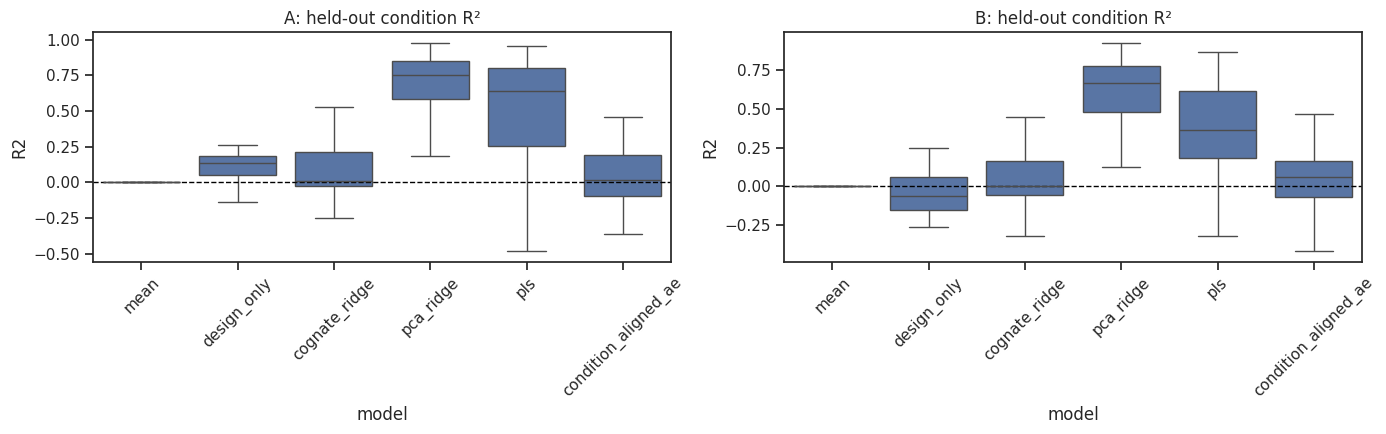

In [7]:
fig, axes = plt.subplots(1, len(DATA), figsize=(7 * len(DATA), 4.5), squeeze=False)
for ax, (lab, tab) in zip(axes[0], R2_TABLES.items()):
    long = tab.reset_index(names="protein").melt(id_vars="protein", var_name="model", value_name="R2")
    sns.boxplot(data=long, x="model", y="R2", ax=ax, showfliers=False)
    ax.axhline(0, ls="--", lw=1, c="black")
    ax.set_title(f"{lab}: held-out condition R²")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "condition_oof_r2.png", dpi=160, bbox_inches="tight")
plt.show()

### Condition-level RMSE

This makes it easy to see whether one held-out treatment/timepoint is systematically difficult for all models.

In [8]:
RMSE = {}
for lab, oof in OOF.items():
    RMSE[lab] = oof_condition_rmse(oof)
    print(f"\n{lab}")
    display(RMSE[lab].pivot(index="condition", columns="model", values="rmse").round(3))


A


model,cognate_ridge,condition_aligned_ae,design_only,mean,pca_ridge,pls
condition,,,,,,
T0|t0,1.413,1.007,1.392,1.520,0.948,0.758
T0|t1,2.110,1.949,1.878,2.259,0.784,1.069
T0|t2,1.907,1.899,1.840,1.975,1.249,1.622
T0|t3,2.160,2.243,2.227,2.271,1.285,1.606
T1|t0,2.007,2.195,2.120,1.987,0.987,1.604
T1|t1,2.001,2.140,1.937,2.082,0.953,1.598
T1|t2,2.385,2.597,2.498,2.573,1.388,1.737
T1|t3,1.553,1.786,1.460,1.819,0.638,0.840



B


model,cognate_ridge,condition_aligned_ae,design_only,mean,pca_ridge,pls
condition,,,,,,
T0|t0,1.321,1.496,1.317,1.314,0.868,1.142
T0|t1,1.037,1.066,1.244,1.021,0.871,1.016
T0|t2,1.649,1.900,1.780,1.711,0.874,1.293
T0|t3,3.539,3.220,3.804,3.781,1.745,2.137
T1|t0,2.224,2.487,2.261,2.378,1.543,2.081
T1|t1,1.281,1.552,1.495,1.332,1.004,0.812
T1|t2,2.380,2.027,2.439,2.463,1.641,2.192
T1|t3,2.313,2.542,2.611,2.424,1.208,2.414


## 6 — Fit the condition-aligned autoencoder on all samples

This fit is for **latent-space interpretation**, not for reporting predictive performance. Predictive claims must come from the out-of-fold results above.

The expected geometry is that RNA and protein samples from the same experimental condition occupy nearby regions in the shared latent space, even though individual replicates are not paired.

In [9]:
FULL = {}
for lab, d in DATA.items():
    print(f"fitting full-data latent model for {lab}...")
    pre, ae, R, P = fit_full_condition_ae(d, pre_kwargs=PRE_KWARGS, ae_kwargs=AE_KWARGS)
    coords = latent_coordinates(d, ae, R, P)
    distances = latent_centroid_distances(d, ae, R, P)
    FULL[lab] = dict(pre=pre, ae=ae, R=R, P=P, coords=coords, distances=distances)
    display(distances.sort_values("latent_centroid_distance"))

fitting full-data latent model for A...


,condition,latent_centroid_distance
2,T0|t1,0.071965
1,T1|t0,0.099332
3,T1|t1,0.114757
5,T1|t2,0.118559
0,T0|t0,0.123194
7,T1|t3,0.144442
4,T0|t2,0.161602
6,T0|t3,0.336988


fitting full-data latent model for B...


,condition,latent_centroid_distance
1,T1|t0,0.417429
5,T1|t2,0.504364
3,T1|t1,0.516844
7,T1|t3,0.532690
6,T0|t3,0.591239
2,T0|t1,0.632537
0,T0|t0,1.094044
4,T0|t2,1.126600


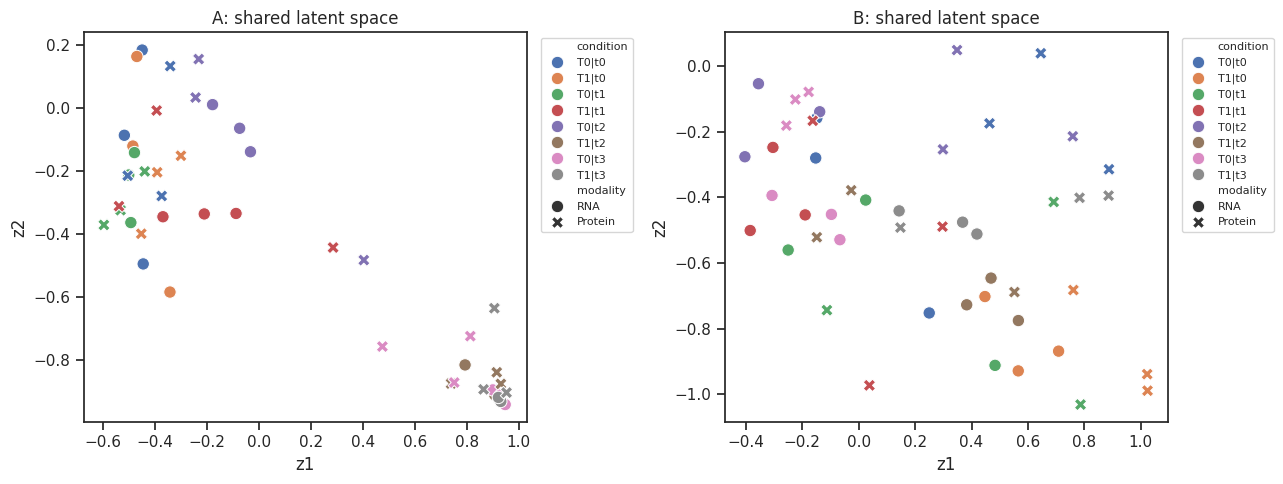

In [10]:
fig, axes = plt.subplots(1, len(DATA), figsize=(6.5 * len(DATA), 5), squeeze=False)
for ax, (lab, obj) in zip(axes[0], FULL.items()):
    z = obj["coords"].reset_index(names="sample")
    if "z2" not in z:
        continue
    sns.scatterplot(
        data=z, x="z1", y="z2", hue="condition", style="modality",
        s=80, ax=ax
    )
    ax.set_title(f"{lab}: shared latent space")
    ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "shared_latent_space.png", dpi=160, bbox_inches="tight")
plt.show()

## 7 — Condition-level RNA–protein residuals

For a held-out condition \(c\) and protein \(p\):

\[
D_{cp} = Protein^{observed}_{cp} - Protein^{predicted\ from\ RNA}_{cp}
\]

These are **condition-level residuals**. They are not individual-sample RNA/protein discordance scores because the biological samples are independent.

Large residuals can identify conditions/proteins for follow-up, but with only ~8 conditions they should initially be treated as **descriptive**, not as strong evidence of post-transcriptional regulation.

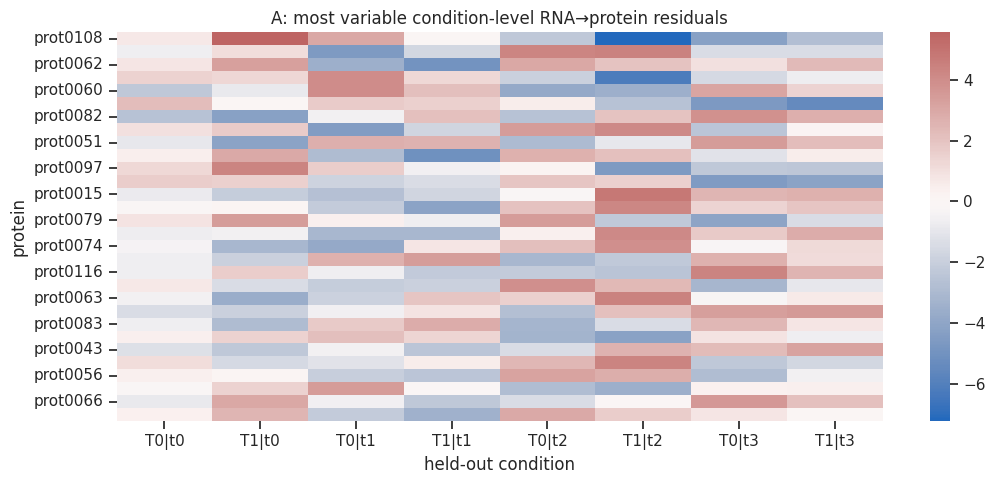

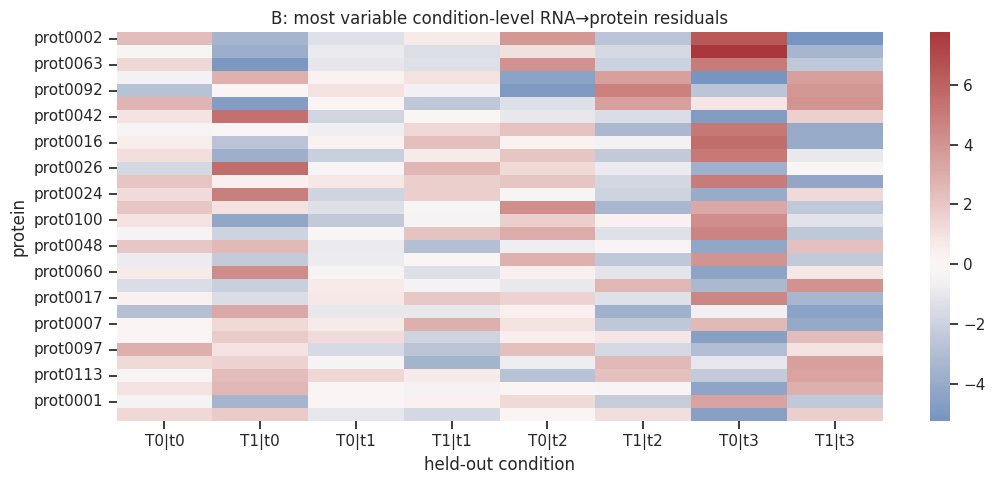

In [11]:
RESIDUALS = {}
for lab, oof in OOF.items():
    D = condition_residuals(oof, model="condition_aligned_ae")
    RESIDUALS[lab] = D
    D.to_csv(OUT_DIR / f"{lab}_condition_residuals.csv")

    top = D.var(axis=0).sort_values(ascending=False).head(min(30, D.shape[1])).index
    plt.figure(figsize=(11, 5))
    sns.heatmap(D.loc[:, top].T, center=0, cmap="vlag")
    plt.title(f"{lab}: most variable condition-level RNA→protein residuals")
    plt.xlabel("held-out condition")
    plt.ylabel("protein")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / f"{lab}_condition_residual_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()

## 8 — Permutation null (optional)

The permutation control shuffles **protein condition labels**, not individual protein rows against RNA rows. This tests whether the condition-level RNA→protein relationship is stronger than expected when the cross-modal condition correspondence is broken.

`N_PERM=5` is only a smoke test. Use at least ~20–50 permutations for an exploratory null and more for stable tail probabilities.

In [12]:
PERM = {}
if RUN_PERMUTATIONS:
    for lab, d in DATA.items():
        print(f"permutations: {lab}")
        PERM[lab] = permutation_null(
            d,
            n_perm=N_PERM,
            seed=SEED,
            pre_kwargs=PRE_KWARGS,
            ae_kwargs=AE_KWARGS,
            pca_components=PCA_COMPONENTS,
            pls_components=PLS_COMPONENTS,
        )
        display(PERM[lab])
else:
    print("Permutation analysis skipped. Set RUN_PERMUTATIONS=True to run it.")

Permutation analysis skipped. Set RUN_PERMUTATIONS=True to run it.


## 9 — Optional cross-variety comparison through orthologs

The varieties are still modelled independently. If you provide an ortholog table, compare prediction performance only after mapping proteins between varieties.

In [13]:
if ORTHOLOG_CSV is not None and len(R2_TABLES) >= 2:
    labs = list(R2_TABLES)[:2]
    a, b = labs
    orth = pd.read_csv(ORTHOLOG_CSV)
    if not {"id_a", "id_b"}.issubset(orth.columns):
        raise ValueError("ortholog file must contain columns id_a and id_b")

    ra = R2_TABLES[a]["condition_aligned_ae"].rename("R2_a").rename_axis("id_a").reset_index()
    rb = R2_TABLES[b]["condition_aligned_ae"].rename("R2_b").rename_axis("id_b").reset_index()
    comp = orth.merge(ra, on="id_a", how="inner").merge(rb, on="id_b", how="inner")
    print(f"orthologs with R² in both varieties: {len(comp)}")
    display(comp.head())
    if len(comp) >= 3:
        print("Spearman R² concordance:", comp[["R2_a", "R2_b"]].corr(method="spearman").iloc[0,1])
else:
    print("No ortholog table configured; per-variety analysis is complete.")

No ortholog table configured; per-variety analysis is complete.


## 10 — Interpretation checklist

Before interpreting the autoencoder biologically:

1. **Do not pair independent replicates.** Matching replicate numbers are not biological pairing.
2. Use **condition-held-out CV** as the primary performance estimate.
3. Compare the autoencoder against `mean`, `design_only`, `cognate_ridge`, `pca_ridge`, and `pls`.
4. Require the autoencoder to show positive held-out R² and preferably improve over simpler baselines before interpreting its residuals strongly.
5. Treat `observed condition mean − predicted condition mean` as a **condition-level residual**, not an individual-sample discordance score.
6. Avoid replicate-specific lag claims (`RNA_rep_i(t) → Protein_rep_i(t+1)`) when the assays were performed on different biological material.
7. Cross-variety comparisons should be performed only after mapping orthologous features.

### Why the AE does not receive treatment/timepoint as input

Treatment/timepoint labels are deliberately used only to define the **alignment groups and CV folds**. They are not concatenated to the AE input. Otherwise the neural network could learn the experimental design directly and appear cross-modally predictive without learning useful transcriptomic information. The `design_only` model is kept as the explicit control for that possibility.
